## Multi-Qubit Systems & Entanglement 

### **Notebook Title: W2: CNOT, Entanglement, and Bell States**

#### 1. Setup and Introduction

* **1.1 Imports:** (Same as Week 1, but we introduce `AerSimulator` for correlation experiments.)

In [ ]:
# W2: CNOT, Entanglement, and Bell States

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
import numpy as np

# Initialize simulator for measurement experiments
sim = AerSimulator()
print("W2 Setup Complete: Ready for Multi-Qubit Magic!")

W2 Setup Complete: Ready for Multi-Qubit Magic!


#### 2. Understanding Multi-Qubit States (Tensor Products)

* **2.1 Product State $ |01\rangle $ :** Understand that a 2-qubit system can be in states like **$ |00\rangle, |01\rangle, |10\rangle, |11\rangle $**.
* **Code:** Create the state $ |01\rangle $ and visualize its state vector (it has 4 components: 00, 01, 10, 11).

--- State |01> (Product State) ---
State Vector (Amplitudes for |00>, |01>, |10>, |11>): [0.+0.j 1.+0.j 0.+0.j 0.+0.j]


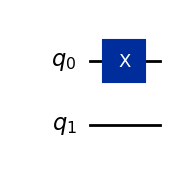

In [3]:
# Create the product state |01> (Qubit 0 is |1>, Qubit 1 is |0>)
qc_product = QuantumCircuit(2)
qc_product.x(0) # Set Qubit 0 to |1>

# Qiskit orders qubits from right to left in the state vector, so it's |q1 q0>
state_product = Statevector.from_instruction(qc_product)

print("--- State |01> (Product State) ---")
print(f"State Vector (Amplitudes for |00>, |01>, |10>, |11>): {state_product.data}")
# Expect [0, 1, 0, 0] if Qiskit orders |q1 q0>
display(qc_product.draw('mpl'))

#### 3. The Controlled-NOT (CNOT) Gate

* **3.1 Definition:** The CNOT gate acts on two qubits: a **Control** and a **Target**.
* It flips the **Target** qubit **ONLY IF** the **Control** qubit is $\|1\rangle$ .

* **3.2 Logic Table and Visualization:**

| Control (Q0) | Target (Q1) | CNOT Result (Q0 Q1) |
| :---: | :---: | :---: |
| $\|0\rangle$ | $\|0\rangle$ | $\|00\rangle$ |
| $\|0\rangle$ | $\|1\rangle$ | $\|01\rangle$ |
| $\|1\rangle$ | $\|0\rangle$ | $\|11\rangle$ |
| $\|1\rangle$ | $\|1\rangle$ | $\|10\rangle$ |

* **Code:** Demonstrate CNOT's flipping action.

Case 1: |00> -> CNOT -> |00>. Success:  True
Case 2: |10> -> CNOT -> |11>. Success:  True


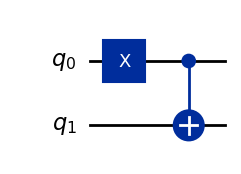

In [12]:
# CNOT Demonstration: Q0=Control, Q1=Target
qc_cnot = QuantumCircuit(2)

# Case 1: Control |0> -> Target is NOT flipped
qc_cnot.cx(0, 1) # Control=0, Target=1
state_00 = Statevector.from_instruction(qc_cnot)
print("Case 1: |00> -> CNOT -> |00>. Success: ", np.allclose(state_00.data, [1, 0, 0, 0]))

# Case 2: Control |1> -> Target IS flipped
qc_cnot_flip = QuantumCircuit(2)
qc_cnot_flip.x(0) # Set control to |1>
qc_cnot_flip.cx(0, 1) 
state_10_flip = Statevector.from_instruction(qc_cnot_flip)
print("Case 2: |10> -> CNOT -> |11>. Success: ", np.allclose(state_10_flip.data, [0, 0, 0, 1]))

display(qc_cnot_flip.draw('mpl'))

#### 4. Creating Entanglement (The Bell State $ |\Phi^{+}\rangle $ )

* **4.1 The Magic Sequence:** Entanglement is created by applying the H-gate followed by the CNOT gate.
1. **H-gate on Q0:** State becomes $ \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)|0\rangle = \frac{1}{\sqrt{2}}(|00\rangle+|10\rangle) $.
2. **CNOT on Q0, Q1:** CNOT only flips Q1 when Q0 is $ |1\rangle $.




* This final state, ** $|\Phi^{+}\rangle $**, is a **Bell state** (maximally entangled).


* **Code:** Build the Bell state circuit.

--- Bell State (|Phi+>) Circuit ---


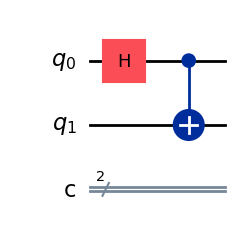

State Vector (Amplitudes for |00>, |01>, |10>, |11>): [0.7071 0.     0.     0.7071]


In [5]:
# Circuit to create the maximally entangled Bell State |Phi+>
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0) # Step 1: Create superposition on Control (Q0)
qc_bell.cx(0, 1) # Step 2: Use CNOT to spread superposition/entangle

print("--- Bell State (|Phi+>) Circuit ---")
display(qc_bell.draw('mpl'))

# Visualize the combined multi-qubit state vector
state_bell = Statevector.from_instruction(qc_bell)
print(f"State Vector (Amplitudes for |00>, |01>, |10>, |11>): {np.round(state_bell.data.real, 4)}")

#### 5. Proving Entanglement via Measurement Correlation

* **5.1 Entanglement Test:** If the qubits are entangled, their measurement results must be **perfectly correlated**. When Q0 is measured as '0', Q1 **must** be '0'. When Q0 is measured as '1', Q1 **must** be '1'.
* **5.2 Code:** Measure the Bell state and plot the histogram.


--- Bell State Measurement Circuit ---


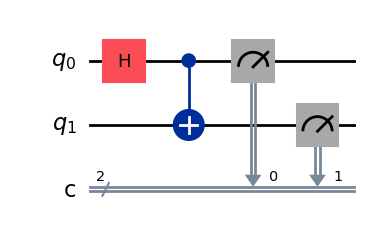


--- Histogram: Proving Correlation ---


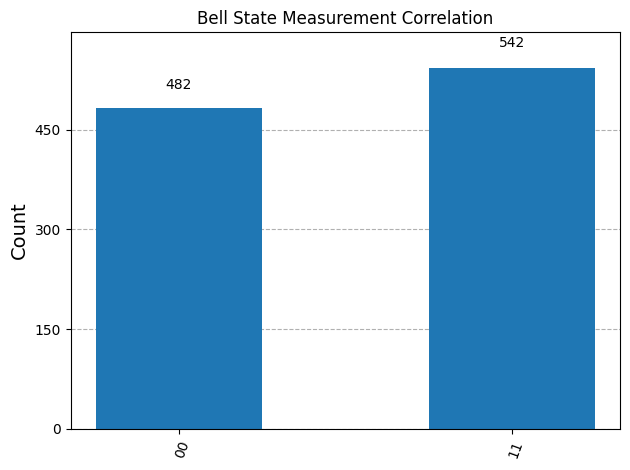

In [6]:
# Add measurement to the Bell circuit
qc_bell_measure = qc_bell.copy()
qc_bell_measure.measure([0, 1], [0, 1]) # Measure Q0->C0, Q1->C1

print("\n--- Bell State Measurement Circuit ---")
display(qc_bell_measure.draw('mpl'))

# Run simulation
result_bell = sim.run(qc_bell_measure, shots=1024).result()
counts_bell = result_bell.get_counts()

print("\n--- Histogram: Proving Correlation ---")
# The histogram should show only two bars: '00' and '11' (about 50% each)
# It should show ZERO counts for '01' and '10'.
display(plot_histogram(counts_bell, title='Bell State Measurement Correlation'))

#### **6. WEEK 2 CHALLENGE (The Other Bell State)**

* **Challenge:** Create the Bell state ** $ |\Psi^{+}\rangle = \frac{1}{\sqrt{2}}(|01\rangle+|10\rangle) $ **.
* *Hint:* You need to apply an additional gate *before* the H-CNOT sequence to change the starting state.


--- W2 CHALLENGE: Bell State |Psi+> Results ---


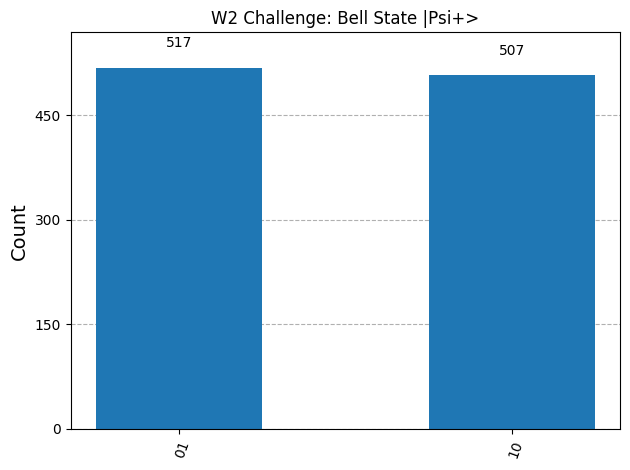

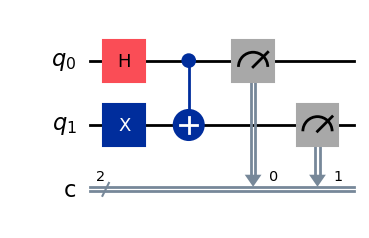

In [14]:
# --- WEEK 2 CHALLENGE CODE BLOCK ---

# Target state: |Psi+> = 1/sqrt(2) * (|01> + |10>)
# Hint: Start with the |01> state before the H-CNOT sequence.

qc_challenge_psi = QuantumCircuit(2, 2)
# Step 1: Set target qubit Q1 to |1>
qc_challenge_psi.x(1) 

# Step 2: Create superposition on Control (Q0)
qc_challenge_psi.h(0) 

# Step 3: Entangle
qc_challenge_psi.cx(0, 1)

qc_challenge_psi.measure([0, 1], [0, 1])

# Run the simulator and check for '01' and '10' counts
result_psi = sim.run(qc_challenge_psi, shots=1024).result()
counts_psi = result_psi.get_counts()

print("\n--- W2 CHALLENGE: Bell State |Psi+> Results ---")
display(plot_histogram(counts_psi, title='W2 Challenge: Bell State |Psi+>'))
draw_qc = qc_challenge_psi.draw('mpl')
display(draw_qc)

This notebook is your hands-on guide to entanglement. Go through the steps, run the CNOT demos, create the  $|\Phi^{+}\rangle$ state, and see the correlation in the histogram.